In [1]:
PRODUCTION_QUALITY = False

import ipdb
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import seaborn as sns
import pandas as pd
import os
import re
import warnings

from labellines import labelLines

plt.style.use(['science', 'bright'])

dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
    'font.size': 12,
    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='10-class-imbalance'

# Beamer 16:9
WIDTH=455.24408

#WIDTH=441.01775
OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'png'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'vit_base_patch16_224.augreg_in21k': 'ViT',
    'resnetv2_50x1_bit.goog_in21k': 'ResNetV2',
}

N_BOOTSTRAP_SAMPLES=100

In [2]:
def set_size(width_pt, fraction=1, subplots=(1, 1), y_scale=False):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt

    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])
    
    if y_scale:
        fig_height_in = fig_height_in * y_scale

    return (fig_width_in, fig_height_in)

In [3]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    figsize = set_size(WIDTH, fraction=fraction, subplots=subplots, y_scale=y_scale)
    fig, axes = plt.subplots(subplots[0], subplots[1], figsize=figsize, constrained_layout=True)

    return fig, axes

In [4]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [9]:
def prepare_data(data):
    records = []
    for experiment_details in data:
        # Extracting values from the JSON structure
        subset_size = experiment_details['configuration']['subset_size']
        imbalance_factor = experiment_details['configuration']['imbalance_factor']
        max_grad_norm = experiment_details['hyperparameters']['max_grad_norm']
                    
        learning_rate = experiment_details['best_params']['learning_rate']
        batch_size = experiment_details['best_params']['batch_size']
        epochs = experiment_details['hyperparameters']['epochs']

        # Handling the full batch size case
        if batch_size == -1:
            full_batch_size = 5000 if subset_size == 0.1 else 50000
            batch_size = full_batch_size

        record = {
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'subset_size': subset_size,
            'imbalance_factor': imbalance_factor,
            'epsilon': experiment_details['hyperparameters']['target_epsilon'],
            'max_grad_norm': max_grad_norm,
            'accuracy': float(experiment_details['best_value']),
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs,
        }

        # Add final metrics also
        for metric_name, metric_value in experiment_details['final_metrics'].items():
            record[metric_name] = metric_value

        records.append(record)

    return pd.DataFrame(records)


In [6]:
def bootstrap_confidence_interval(group, field, n_iterations=N_BOOTSTRAP_SAMPLES, ci=95):
    bootstrapped_means = []
    for _ in range(n_iterations):
        # Resample with replacement and calculate mean
        sample = group.sample(frac=1, replace=True)
        bootstrapped_means.append(sample[field].mean())

    # Calculating the confidence interval
    lower_bound = np.percentile(bootstrapped_means, (100 - ci) / 2)
    upper_bound = np.percentile(bootstrapped_means, 100 - (100 - ci) / 2)

    return lower_bound, upper_bound

# Accuracy trends

In [85]:
def plot_accuracy_trends(prepared_data, output_dir=None):
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'imbalance_factor', 'epsilon', 'max_grad_norm', 'epochs'], inplace=True)
    groups = prepared_data.groupby(['model_name', 'dataset_name', 'subset_size', 'imbalance_factor', 'epochs'])

    for (model, dataset, subset, imbalance_factor, epochs), group in groups:
        fig, ax = get_figure((1, 1))
        model_name = MODEL_NAME_MAP.get(model, model)

        grouped_by_epsilon = group.groupby('epsilon')

        for epsilon, eps_data in grouped_by_epsilon:
            color = next(ax._get_lines.prop_cycler)['color']
            eps_data = eps_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = eps_data.groupby('max_grad_norm')
            ci_lower_acc = []
            ci_upper_acc = []
            mean_accuracy = []
            ci_lower_micro = []
            ci_upper_micro = []
            mean_accuracy_micro = []
            grad_norms = []

            for grad_norm, grad_group in grad_norm_grouped:
                lower_acc, upper_acc = bootstrap_confidence_interval(grad_group, 'MulticlassAccuracy') if len(grad_group) > 1 else (grad_group['MulticlassAccuracy'].values[0], grad_group['MulticlassAccuracy'].values[0])
                lower_micro, upper_micro = bootstrap_confidence_interval(grad_group, 'MulticlassAccuracyWithMicro') if len(grad_group) > 1 else (grad_group['MulticlassAccuracyWithMicro'].values[0], grad_group['MulticlassAccuracyWithMicro'].values[0])

                ci_lower_acc.append(lower_acc)
                ci_upper_acc.append(upper_acc)
                mean_accuracy.append(grad_group['MulticlassAccuracy'].mean())
                ci_lower_micro.append(lower_micro)
                ci_upper_micro.append(upper_micro)
                mean_accuracy_micro.append(grad_group['MulticlassAccuracyWithMicro'].mean())
                grad_norms.append(grad_norm)

            ax.plot(grad_norms, mean_accuracy, label=f'$\epsilon={epsilon}$ (macro)', marker='o', linestyle='-', color=color)
            ax.fill_between(grad_norms, ci_lower_acc, ci_upper_acc, alpha=0.2, color=color)

            ax.plot(grad_norms, mean_accuracy_micro, label=f'$\epsilon={epsilon}$ (micro)', marker='o', linestyle='--', color=color)
            ax.fill_between(grad_norms, ci_lower_micro, ci_upper_micro, alpha=0.2, color=color)

        if imbalance_factor != 0:
            ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, Imbalance Factor {imbalance_factor}, {epochs} Epochs)')
        else:
            ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, Balanced, {epochs} Epochs)')
            
        ax.set_xlabel('Maximum Gradient Norm')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1.05])
        ax.set_xscale('log')

        unique_grad_norms = np.unique(group['max_grad_norm'])
        ax.set_xticks(unique_grad_norms)
        ax.set_xticklabels([f'{x:.3f}' for x in unique_grad_norms], rotation=45)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)

        # Save plot if output_dir is provided
        if output_dir:
            plt.savefig(os.path.join(output_dir, f'grad_norm_variation_accuracy_trends_{model_name}_{dataset}_subset{int(subset*100)}_imbalance{imbalance_factor}_epochs{epochs}.{IMG_FORMAT}'), bbox_inches='tight')

        plt.show()


In [86]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends(processed_data, output_dir=OUTPUT_DIR)

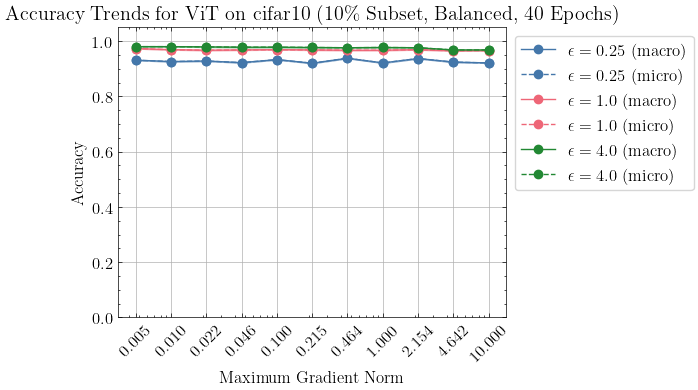

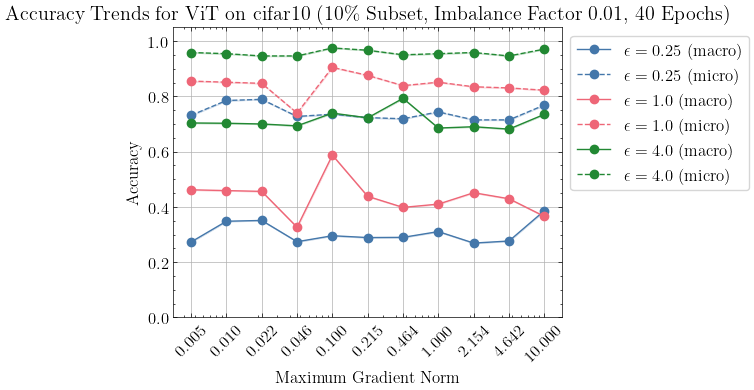

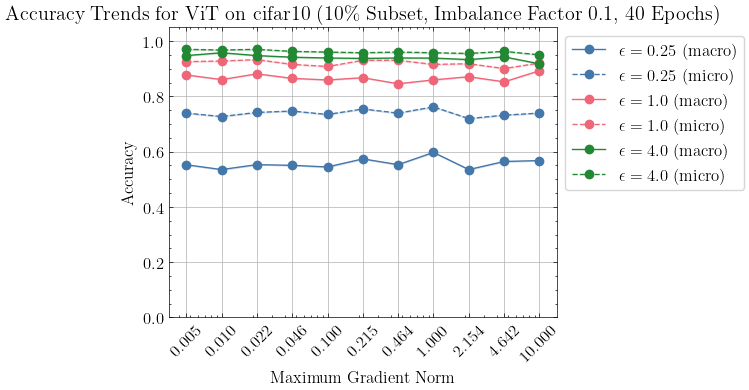

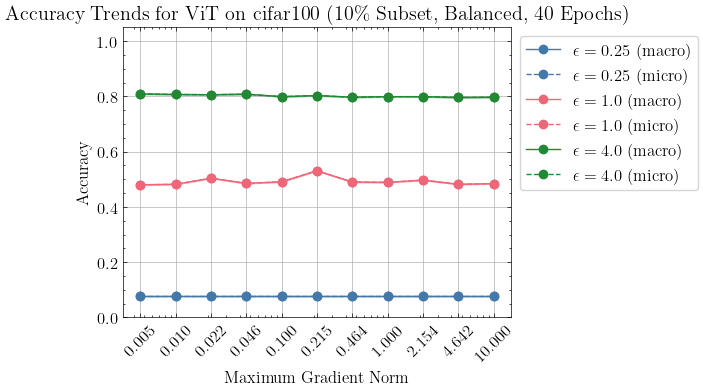

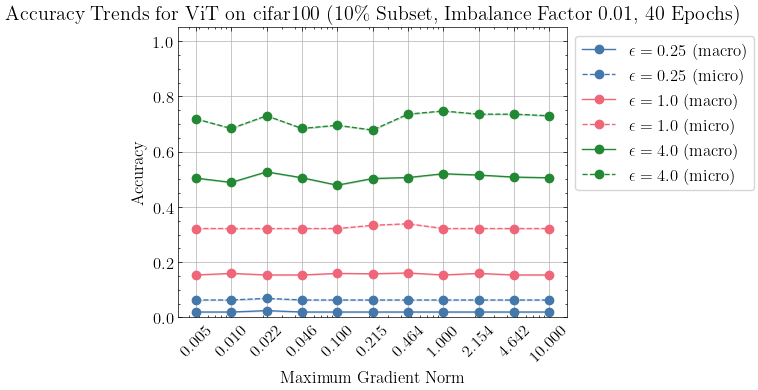

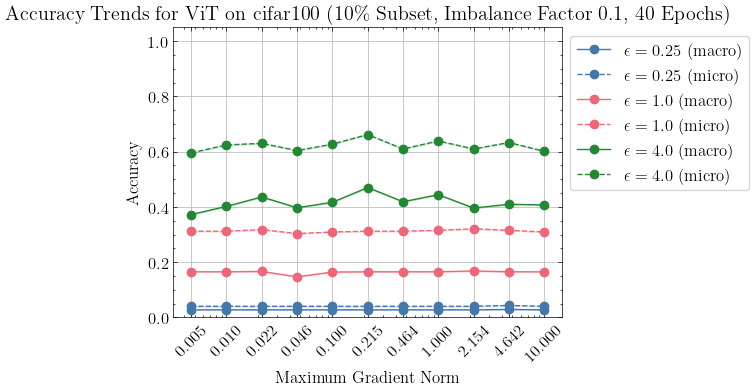

In [87]:
plot()

In [88]:
def plot_accuracy_trends_by_epsilon(prepared_data, output_dir=None):
    prepared_data.sort_values(['model_name', 'dataset_name', 'subset_size', 'epsilon', 'max_grad_norm', 'epochs'], inplace=True)
    grouped_by_epsilon = prepared_data.groupby(['dataset_name', 'subset_size', 'epsilon'])

    for (dataset, subset, epsilon), group in grouped_by_epsilon:
        fig, ax = get_figure((1, 1))
        color_cycle = ax._get_lines.prop_cycler
        model_name = MODEL_NAME_MAP.get(group['model_name'].iloc[0], group['model_name'].iloc[0])

        grouped_by_imbalance = group.groupby('imbalance_factor')

        for imbalance_factor, imbalance_data in grouped_by_imbalance:
            color = next(color_cycle)['color']
            imbalance_data = imbalance_data.sort_values(by='max_grad_norm')

            grad_norm_grouped = imbalance_data.groupby('max_grad_norm')
            ci_lower_acc = []
            ci_upper_acc = []
            mean_accuracy = []
            ci_lower_micro = []
            ci_upper_micro = []
            mean_accuracy_micro = []
            grad_norms = []

            for grad_norm, grad_group in grad_norm_grouped:
                lower_acc, upper_acc = bootstrap_confidence_interval(grad_group, 'MulticlassAccuracy') if len(grad_group) > 1 else (grad_group['MulticlassAccuracy'].values[0], grad_group['MulticlassAccuracy'].values[0])
                lower_micro, upper_micro = bootstrap_confidence_interval(grad_group, 'MulticlassAccuracyWithMicro') if len(grad_group) > 1 else (grad_group['MulticlassAccuracyWithMicro'].values[0], grad_group['MulticlassAccuracyWithMicro'].values[0])

                ci_lower_acc.append(lower_acc)
                ci_upper_acc.append(upper_acc)
                mean_accuracy.append(grad_group['MulticlassAccuracy'].mean())
                ci_lower_micro.append(lower_micro)
                ci_upper_micro.append(upper_micro)
                mean_accuracy_micro.append(grad_group['MulticlassAccuracyWithMicro'].mean())
                grad_norms.append(grad_norm)

            macro_label = f'Imbalance {imbalance_factor} (macro)' if imbalance_factor != 0 else 'Balanced (macro)'
            ax.plot(grad_norms, mean_accuracy, label=macro_label, marker='o', linestyle='-', color=color)
                
            ax.fill_between(grad_norms, ci_lower_acc, ci_upper_acc, alpha=0.2, color=color)

            micro_label = f'Imbalance {imbalance_factor} (micro)' if imbalance_factor != 0 else 'Balanced (micro)'
            ax.plot(grad_norms, mean_accuracy_micro, label=micro_label, marker='o', linestyle='--', color=color)
            ax.fill_between(grad_norms, ci_lower_micro, ci_upper_micro, alpha=0.2, color=color)

        ax.set_title(f'Accuracy Trends for {model_name} on {dataset} ({int(subset*100)}\% Subset, $\epsilon={epsilon}$, {group["epochs"].iloc[0]} Epochs)')
        ax.set_xlabel('Maximum Gradient Norm')
        ax.set_ylabel('Accuracy')
        ax.set_ylim([0, 1.05])
        ax.set_xscale('log')

        unique_grad_norms = np.unique(group['max_grad_norm'])
        ax.set_xticks(unique_grad_norms)
        ax.set_xticklabels([f'{x:.3f}' for x in unique_grad_norms], rotation=45)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        ax.grid(True)

        if output_dir:
            plt.savefig(os.path.join(output_dir, f'grad_norm_variation_accuracy_trends_{model_name}_{dataset}_subset{int(subset*100)}_epsilon{epsilon}_epochs{group["epochs"].iloc[0]}.{IMG_FORMAT}'), bbox_inches='tight')

        plt.show()


In [89]:
def plot():
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    plot_accuracy_trends_by_epsilon(processed_data, output_dir=OUTPUT_DIR)

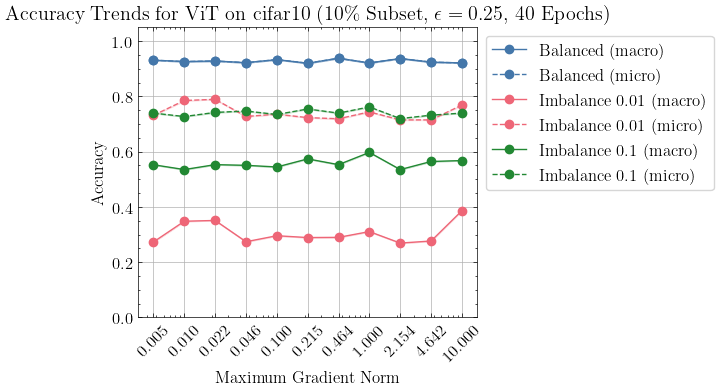

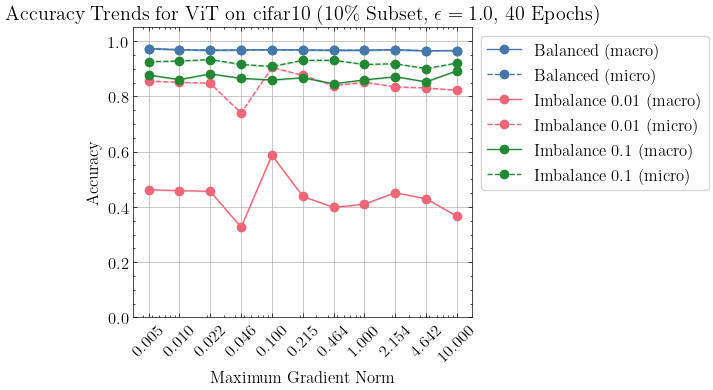

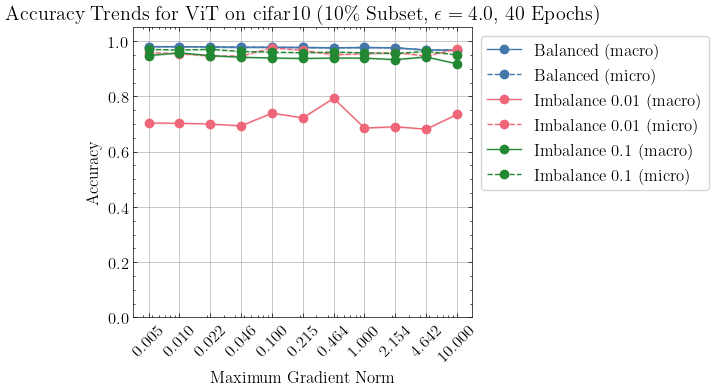

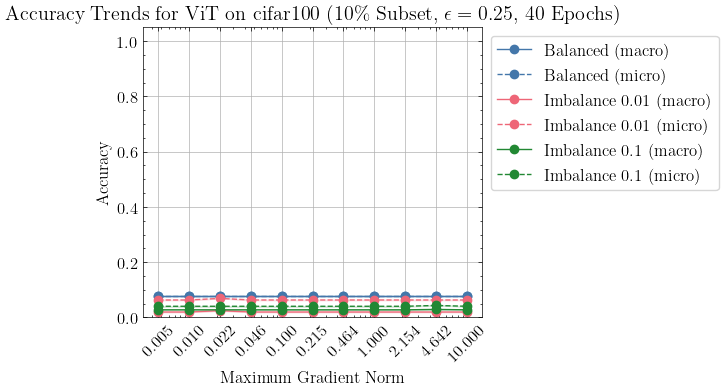

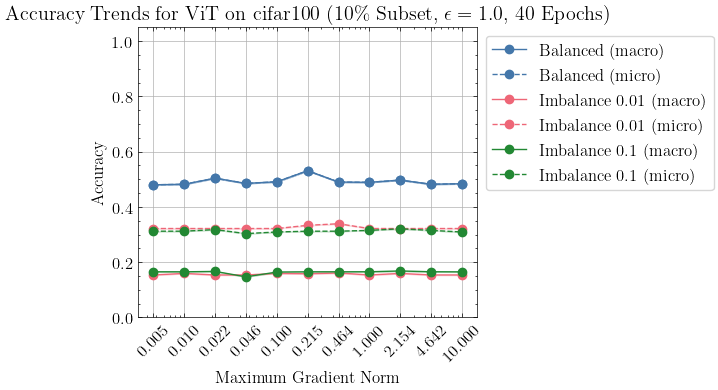

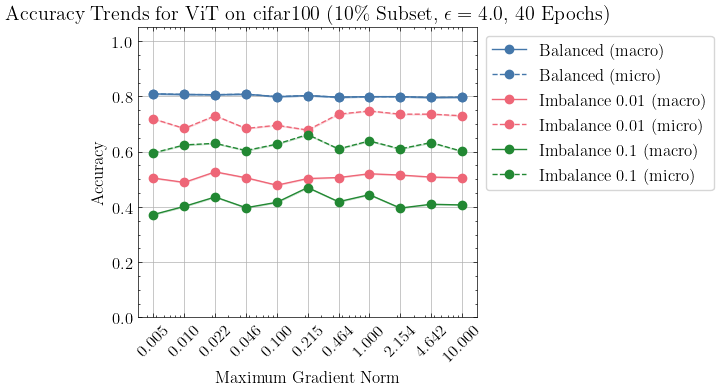

In [90]:
plot()